In [1]:
%run general_functions.ipynb

In [2]:
path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/last_decade/'

In [4]:
dic = xr.open_dataset(path+'dic_baseline_126.nc')
co2flux = xr.open_dataset(path+'co2flux_baseline_126.nc')
mld = xr.open_dataset(path+'mld_baseline_126.nc')
npp = xr.open_dataset(path+'npp_baseline_126.nc')
sst = xr.open_dataset(path+'sst_baseline_126.nc')

In [5]:
npp

<xarray.Dataset>
Dimensions:            (time_counter: 1020, bnds: 2, y: 106, x: 76, deptht: 10)
Coordinates:
  * time_counter       (time_counter) datetime64[ns] 2015-01-16T12:00:00 ... ...
    nav_lon            (y, x) float32 ...
    nav_lat            (y, x) float32 ...
  * deptht             (deptht) float32 3.047 9.454 16.36 ... 63.88 77.62 93.59
Dimensions without coordinates: bnds, y, x
Data variables:
    time_counter_bnds  (time_counter, bnds) datetime64[ns] ...
    deptht_bnds        (deptht, bnds) float32 ...
    bgc_diag_pp        (time_counter, deptht, y, x) float64 ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.5
    name:         FOCI2.0-NM004_FM_ESM_SSP126os_2014CC105_1m_20150101_20151231
    description:  diagnostics 2d bio
    title:        diagnostics 2d bio
    production:   An IPSL model
    timeStamp:    2022-Apr-04 13:54:06 CEST
    history:      Wed Jun 18 10:17:49 2025: cdo -mergetime -apply,-selname,bg...
    NCO:          netCDF Operators version 4.9.1 (Homepage = http://nco.sf.ne...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [6]:
mesh_mask = xr.open_dataset(path+'mesh_mask.nc')

In [7]:
mesh_mask = mesh_mask.tmask.isel(t=0,z=0).sel(x=slice(520, 595), y=slice(330, 435))
mesh_mask = mesh_mask.where(mesh_mask)

In [8]:
# variable units
units = var_units()
# labels
lat_labels, lon_labels = lat_lon_labels()

In [9]:
def geo_weight(data):
    
    weights = np.cos(np.deg2rad(data.nav_lat))
    weights.name = "weights"

    data_weighted = data.weighted(weights)
    weighted_mean = data_weighted.mean(dim=("x"))
    
    return weighted_mean

In [10]:
def ns_polygon(data):
    polygon_coords = [(42,70),(55, 80), (69, 53), (58, 34),(41, 61)]
    
    x = data['x'].values
    y = data['y'].values
    
    X, Y = np.meshgrid(x, y)
    points = np.vstack((X.ravel(), Y.ravel())).T
    
    poly_path = Path(polygon_coords)
    ns_mask = poly_path.contains_points(points).reshape(X.shape)

    return ns_mask

In [11]:
def depth_mask(data, var, depth):
    d = copy.deepcopy(data)
    attrs = d[var].attrs.copy()

    mask = ns_polygon(d)
    d = (d * mask).isel(time_counter=0)

    d = d.where(d)

    d[var] = d[var].notnull().astype(int)
    
    mask_sum = d[var].sum(dim=depth).astype(int)

    depth_levels = xr.DataArray(data[depth].values, dims=[depth], coords={depth: data[depth]})
    mask_depth_values = mask_sum.copy()

    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)

    mask_ds = mask_depth_values.to_dataset(name='depth')
    mask_ds = mask_ds.where(mask_ds['depth'].notnull())

    mask_ds = (mask_ds * mask)
    mask_ds = mask_ds.where(mask_ds)

    return mask_ds

In [12]:
# bathymetry = depth_mask(dic, 'DIC', 'deptht')

In [13]:
def slicing(data, mld, var):
    
    mld_bool = (data['deptht'] < mld.somxl010).to_dataset(name='mld') 
    data *= mld_bool['mld']
    data = data.where(data).fillna(0)
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    
    weighted_var = (sum(layers_sum) / mld.somxl010).to_dataset(name=var)
    
    return weighted_var

In [14]:
def monthly_means(data, var):

    attrs = data[var].attrs
    
    if 'deptht' in data.dims:
        data = data.isel(deptht=0)
        
    mask = ns_polygon(data)
    # if var == 'DIC':
    #     data = slicing(data, mld, var)

    data = data.sel(time_counter=slice('2090','2100'))
    m_lenght = data.time_counter.dt.days_in_month
    data[var] = (data[var] * m_lenght).groupby("time_counter.month").mean(dim="time_counter") / m_lenght.groupby("time_counter.month").mean(dim="time_counter")

    data[var] = data[var].transpose('month','y','x')

    data[var] = (data[var] * mask)
    
    data = data.where(data)
    data = geo_weight(data[var]).to_dataset(name=var)
    data = data.dropna(dim='y')

    # data[var].attrs = attrs

    return data

In [15]:
def homvoller(data, var, ax, vmin, vmax):
    im = data[var].T.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    if var == 'co2flux':
        extend = 'both'
    else:
        extend = 'max'
        
    c = plt.colorbar(im, ax=ax, aspect=12, pad=0.02, location='top', extend=extend)                       
    c.outline.set_linewidth(0.25)
    c.ax.tick_params(labelsize=12)

    c.set_label(
            f"{list(units[var].keys())[0]} [{list(units[var].values())[0]}]",
            labelpad=14
        )
    
    return im

In [16]:
cmap, norm = create_discrete_cmap(cm.rainforest_r,40)

In [17]:
# mld_f = monthly_means(mld, 'somxl010')
# npp_f = monthly_means(npp, 'bgc_diag_pp')
# sst_f = monthly_means(sst, 'sosstsst')
# co2flux_f = monthly_means(co2flux, 'co2flux')
# dic_f = monthly_means(dic, 'DIC')

In [34]:
d = '$^\circ$'

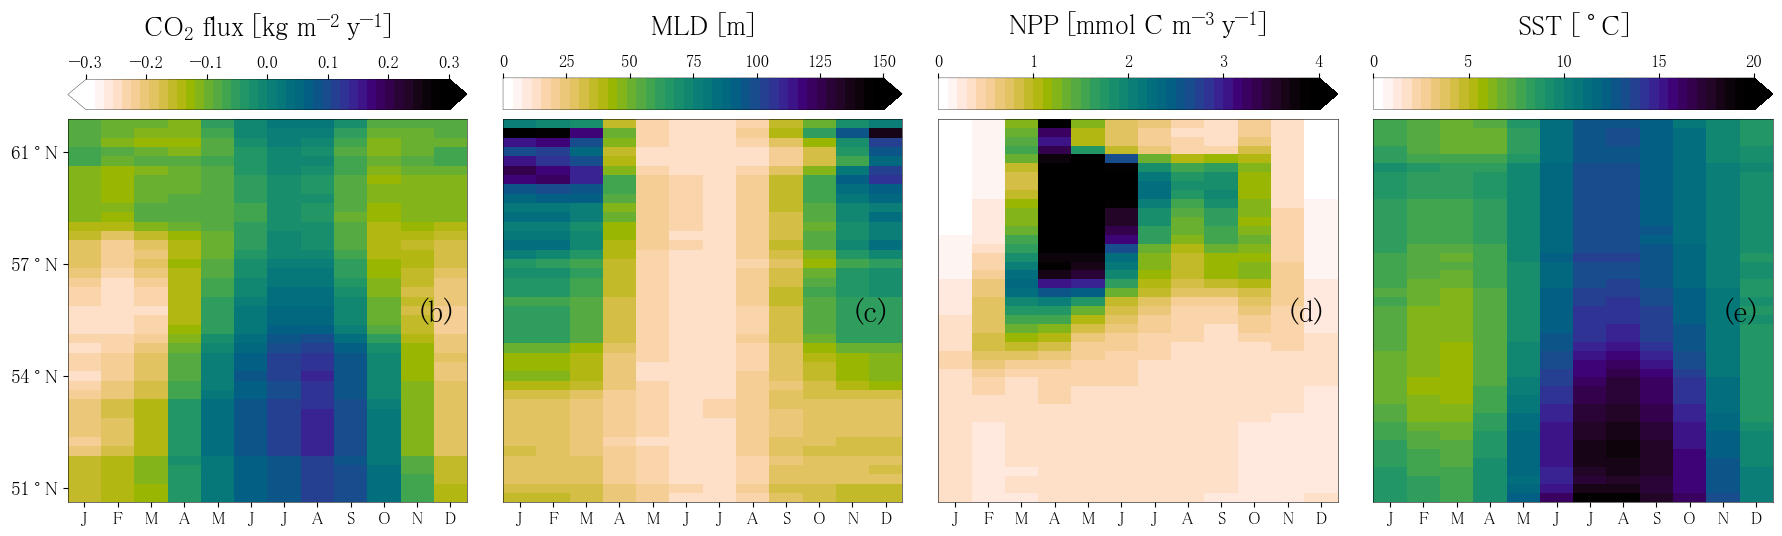

In [52]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    ncols=4,
    figsize=(22, 6),
    # gridspec_kw={'width_ratios': [1.5, 1, 1, 1]}
)
plt.subplots_adjust(wspace=0.09)

# im = ax1.pcolormesh(
#         mesh_mask,
#         cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
#     )

# im = ax1.pcolormesh(
#         bathymetry['depth'],
#         cmap=cmap,
#         vmin=0,
#         vmax=300
#     )

                            # year
im_co2flux = homvoller(co2flux_f*31536000, 'co2flux', ax1, -0.3, 0.3)
im_mld = homvoller(mld_f, 'somxl010', ax2, 0, 150)
im_npp = homvoller(npp_f*31536000, 'bgc_diag_pp', ax3, 0, 4)
im_sst = homvoller(sst_f, 'sosstsst', ax4, 0, 20)

# im_dic = homvoller(dic, 'DIC', ax4, 1500, 2000)

# cbar = plt.colorbar(im, ax=ax1, aspect=18, pad=0.02, location='top', extend='max')
# cbar.outline.set_linewidth(0.25)
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label('North Sea bathymetry [m]', labelpad=14)

for ax in [ax2,ax3,ax4]:
    month_x_labels(ax)
    ax.axes.get_yaxis().set_visible(False)
    
ax1.set_yticks([1,13,25,37])
ns_labels = [f'51{d}N', f'54{d}N',f'57{d}N', f'61{d}N']
ax1.set_yticklabels(ns_labels, fontsize=14)
month_x_labels(ax1)

for n, ax in enumerate([ax1,ax2,ax3,ax4]):
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    for location in ['left','bottom', 'right', 'top']:
        ax.spines[location].set_linewidth(0.4)
                                                    # -- change this when updating figure --
    ax.text(0.88, .47, string.punctuation[7] + string.ascii_lowercase[n+1] + string.punctuation[8],
        transform=ax.transAxes, size=22, weight='bold', color='black')

pass

# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/northSea_updated.png')